# Chapter 16 — Data formats & talking to the ecosystem

> **This chapter runs end-to-end on the plain `jansky` base environment, with no
> network and no optional extras.** Every heavy tool of the radio-astronomy
> software world — `blimpy`, `turboSETI`, `pyuvdata`, VIRGO/PICTOR, CASA — is
> guarded in `try/except` so that when it is absent (as it is here) the notebook
> prints a note, an install hint, and falls back to an offline path. The *data
> formats themselves* we exercise for real, byte-for-byte, using
> [`jansky.formats`](https://github.com/joebarbere/jansky/blob/main/src/jansky/formats.py).

By now you have followed radio data a long way: complex **IQ samples** from a
software radio ([Chapter 5](05_sdr_basics.ipynb)), calibrated **visibilities** in
a Measurement Set ([Chapter 12](12_vla_imaging.ipynb)), and **folded pulsar**
data in PSRFITS ([Chapter 13](13_pulsars.ipynb)). Each of those lived in a
*format*, and each format has *tools* that read it. This chapter is the connective
tissue: the file formats radio astronomers actually pass around, and the software
ecosystem that produces and consumes them.

## What you'll learn

- The **data-format pipeline**: raw voltages → channelised spectra → spectra /
  visibilities → images, and which format sits at each stage (the reference table
  lives in [`docs/data-formats.md`](https://github.com/joebarbere/jansky/blob/main/docs/data-formats.md)).
- How to **write and read real GUPPI raw** voltage files — the Green Bank /
  Breakthrough Listen format — with `jansky.formats`.
- The shape of a **SETI Doppler-drift search**: why an interstellar beacon drifts
  in frequency, and a tiny de-drift-and-integrate detector that recovers one.
- **SigMF**, the open, portable format for SDR recordings (JSON sidecar + raw
  samples), round-tripped end-to-end.
- How to **stream spectra to Radio-Sky Spectrograph** over its real TCP protocol,
  exercised here against an in-process mock server.
- The **wider ecosystem**: `pyuvdata` / RASG for visibility interchange,
  VIRGO/PICTOR as a no-hardware hydrogen-line route, and CASA for Measurement Sets.

## 1. Orientation — the format landscape

Radio data is not one thing; it is a *chain* of representations, each a lossy or
lossless transformation of the last. A useful mental model:

$$
\underbrace{\text{raw voltages}}_{\text{GUPPI raw, SigMF}}
\;\longrightarrow\;
\underbrace{\text{channelised}}_{\text{filterbank, HDF5/UVH5}}
\;\longrightarrow\;
\begin{cases}
\underbrace{\text{spectra}}_{\text{.sps, .spd}} \\[4pt]
\underbrace{\text{visibilities}}_{\text{UVFITS, Measurement Set}} \\[4pt]
\underbrace{\text{pulsars}}_{\text{PSRFITS}}
\end{cases}
\;\longrightarrow\;
\underbrace{\text{images}}_{\text{FITS}}
$$

Read it left to right as **time → information**. At the far left a digitiser hands
you the antenna voltage itself as complex samples; nothing has been thrown away,
but the volume is enormous. A **channeliser** (a polyphase filterbank / FFT) turns
those voltages into power-vs-frequency-vs-time — a *waterfall* — collapsing the
data by orders of magnitude. From there the path forks by science case: a
single-dish spectrometer writes **spectra**, a correlator writes **visibilities**
that get imaged, and a pulsar backend folds into **PSRFITS**.

| Stage | Format(s) | Read with |
|---|---|---|
| Raw voltages | **GUPPI raw**, **SigMF** | `jansky.formats`, `blimpy` |
| Channelised | SIGPROC filterbank, HDF5 / UVH5 | `blimpy`, `pyuvdata` |
| Spectra | `.sps`, `.spd` (Radio-Sky) | `jansky.formats` (live), readers deferred |
| Visibilities | UVFITS, Measurement Set | `pyuvdata`, CASA *(Ch 12)* |
| Pulsars | PSRFITS | `astropy.io.fits` *(Ch 13)* |
| Images | FITS | `astropy.io.fits` |

This chapter walks the **top-left of that chain** hands-on — the part the rest of
the course has not yet touched — then surveys the tools for everything downstream.
Full reference: [`docs/data-formats.md`](https://github.com/joebarbere/jansky/blob/main/docs/data-formats.md).

## Setting up

We import the scientific stack, the `jansky` helpers, and `jansky.formats` — the
module this whole chapter is about. We call `plotting.use_jansky_style()` so the
figures match the rest of the course, seed a generator from `signals.rng`, and put
all of this chapter's scratch files in a temporary directory so nothing is left
behind.

In [1]:
%matplotlib inline
import json
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from jansky import signals, plotting, formats

plotting.use_jansky_style()

# Reproducible randomness for every figure and file in this chapter.
SEED = 1960  # Project Ozma, the first modern SETI search (Frank Drake)
rng = signals.rng(SEED)

# A throwaway working directory for the example files we write and read back.
WORKDIR = Path(tempfile.mkdtemp(prefix="jansky_ch16_"))
print(f"scratch directory: {WORKDIR}")
print("jansky.formats provides:", ", ".join(formats.__all__))

scratch directory: /tmp/jansky_ch16_bzijhsq0
jansky.formats provides: Spectrogram, save_spectrogram, load_spectrogram, read_guppi_header, write_guppi, iter_guppi_blocks, read_sigmf, write_sigmf, RSSClient, MockRSSServer, rss_handshake, encode_rss_sweep, decode_rss_sweep, read_filterbank, read_sps, read_spd


## 2. GUPPI raw, hands-on

**GUPPI raw** (Green Bank Ultimate Pulsar Processing Instrument) is the raw-voltage
format used by Green Bank backends and by **Breakthrough Listen**, the largest SETI
program. Its layout is deliberately FITS-flavoured and simple:

- a header of **80-byte ASCII cards**, `KEYWORD = value`, terminated by an `END`
  card — the same card grammar as FITS;
- then `BLOCSIZE` bytes of voltage data, stored as **interleaved int8 I/Q**
  (8-bit real, 8-bit imaginary) ordered `[channel][time][polarisation]`.

`jansky.formats` ships a minimal writer and reader so we can make our own example
files. Let's synthesise a tiny capture: a handful of channels of integer-valued
complex noise, with **one channel carrying a coherent tone** so we can see it stand
out in power. We then write it with `formats.write_guppi`, parse the header back
with `formats.read_guppi_header`, and stream the voltages with
`formats.iter_guppi_blocks`.

In [2]:
# Synthetic raw voltages: (nchan, ntime, npol), integer-valued complex (int8 range).
NCHAN, NTIME, NPOL = 8, 4096, 2
TONE_CHAN = 5  # the channel we will inject a coherent carrier into

# Background: low-level integer complex noise in every channel/pol.
real = rng.integers(-8, 9, size=(NCHAN, NTIME, NPOL))
imag = rng.integers(-8, 9, size=(NCHAN, NTIME, NPOL))
volts = real + 1j * imag

# Inject a coherent tone into one channel (both pols): a rotating phasor.
n = np.arange(NTIME)
tone = 30.0 * np.exp(1j * 2 * np.pi * 0.12 * n)         # amplitude ~30 (well under int8)
volts[TONE_CHAN, :, 0] += tone
volts[TONE_CHAN, :, 1] += tone * np.exp(1j * 0.4)        # small inter-pol phase offset

# A few descriptive header cards on top of the ones write_guppi fills in
# (BLOCSIZE, OBSNCHAN, NPOL, NBITS are derived from the data automatically).
extra_header = {
    "TELESCOP": "GBT",
    "OBSFREQ": 1420.0,     # MHz, band centre (flavour: the HI line)
    "OBSBW": 2.0,          # MHz total bandwidth
    "TBIN": 1.0e-6,        # s, sample time
    "SRC_NAME": "JANSKY16",
}

raw_path = WORKDIR / "jansky16.0000.raw"
formats.write_guppi(raw_path, volts, header=extra_header)
print(f"wrote {raw_path.name}  ({raw_path.stat().st_size:,} bytes)")
print(f"  data array: {volts.shape} complex, channel {TONE_CHAN} carries a tone")

wrote jansky16.0000.raw  (131,952 bytes)
  data array: (8, 4096, 2) complex, channel 5 carries a tone


### Reading the header back

`read_guppi_header` parses only the ASCII cards of the first block (cheap — it never
touches the voltages) and returns a plain dict. Notice the keys the writer filled in
from the data shape (`BLOCSIZE`, `OBSNCHAN`, `NPOL`, `NBITS`) sitting alongside the
descriptive cards we supplied.

In [3]:
header = formats.read_guppi_header(raw_path)
print("GUPPI header (parsed ASCII cards):")
for key, val in header.items():
    print(f"  {key:<9}= {val!r}")

# Sanity checks against what we wrote.
assert header["OBSNCHAN"] == NCHAN
assert header["NPOL"] == NPOL
assert header["NBITS"] == 8
assert header["BLOCSIZE"] == NCHAN * NTIME * NPOL * 2  # int8 I + int8 Q per sample
print(f"\nBLOCSIZE {header['BLOCSIZE']:,} bytes "
      f"= {NCHAN} chan x {NTIME} time x {NPOL} pol x 2 (I,Q int8)  -- checks out")

GUPPI header (parsed ASCII cards):
  BLOCSIZE = 131072
  OBSNCHAN = 8
  NPOL     = 2
  NBITS    = 8
  DIRECTIO = 0
  TELESCOP = 'GBT'
  OBSFREQ  = 1420.0
  OBSBW    = 2.0
  TBIN     = 1e-06
  SRC_NAME = 'JANSKY16'

BLOCSIZE 131,072 bytes = 8 chan x 4096 time x 2 pol x 2 (I,Q int8)  -- checks out


### Streaming the voltages and a power-vs-channel plot

`iter_guppi_blocks` yields `(header, voltages)` for each block, reconstructing the
complex `(nchan, ntime, npol)` array from the interleaved int8 samples. We integrate
the power $|v|^2$ over time and polarisation to get **power vs channel** — and the
channel we spiked should tower over the noise.

block: voltages (8, 4096, 2) complex64
loudest channel: 5  (injected tone was in channel 5)


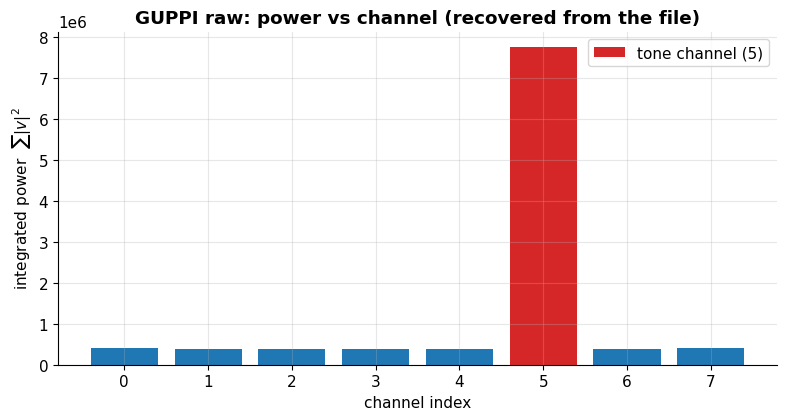

In [4]:
powers = None
for blk_header, blk_volts in formats.iter_guppi_blocks(raw_path):
    # Power summed over time and polarisation, per channel.
    powers = np.sum(np.abs(blk_volts) ** 2, axis=(1, 2))
    print(f"block: voltages {blk_volts.shape} {blk_volts.dtype}")

assert powers is not None
loud = int(np.argmax(powers))
print(f"loudest channel: {loud}  (injected tone was in channel {TONE_CHAN})")
assert loud == TONE_CHAN

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(np.arange(NCHAN), powers, color="#1f77b4")
ax.bar(TONE_CHAN, powers[TONE_CHAN], color="#d62728", label=f"tone channel ({TONE_CHAN})")
ax.set_xlabel("channel index")
ax.set_ylabel(r"integrated power  $\sum |v|^2$")
ax.set_title("GUPPI raw: power vs channel (recovered from the file)")
ax.legend()
fig.tight_layout()
plt.show()

**The Breakthrough Listen pipeline.** In real SETI work you do *not* analyse GUPPI
raw directly. The standard chain is:

1. **`rawspec`** — a GPU channeliser that reduces `.raw` voltages to a SIGPROC
   **filterbank** (`.fil`) or HDF5 waterfall;
2. **`blimpy`** — reads filterbank/HDF5 and gives you a NumPy waterfall;
3. **`turboSETI`** — runs the Doppler-drift search (next section) at scale.

`blimpy` is an optional extra (`uv sync --extra seti`). We guard the import so the
notebook still runs without it — and on this base environment, it is absent:

In [5]:
try:
    import blimpy  # noqa: F401
    HAVE_BLIMPY = True
    print(f"blimpy {blimpy.__version__} is available -- you can read real .fil/.h5 waterfalls.")
    print("  e.g.  wf = jansky.formats.read_filterbank('observation.fil')")
except Exception as exc:
    HAVE_BLIMPY = False
    print(f"blimpy not available ({type(exc).__name__}) -> using the simulated path below.")
    print("  install with:  uv sync --extra seti   (brings blimpy + turboSETI)")
    print("  then:  rawspec observation.raw   ->   .fil   ->   blimpy/turboSETI")

blimpy not available (ModuleNotFoundError) -> using the simulated path below.
  install with:  uv sync --extra seti   (brings blimpy + turboSETI)
  then:  rawspec observation.raw   ->   .fil   ->   blimpy/turboSETI


## 3. A SETI Doppler-drift search (simulated)

Why would an interstellar beacon *drift* in frequency? Because the transmitter and
the receiver are accelerating relative to one another — planetary rotation and
orbital motion impose a time-varying Doppler shift. A signal emitted at a fixed
frequency $f_0$ therefore arrives with a frequency that ramps linearly,

$$ f(t) \;=\; f_0 \;+\; \dot f \, t, $$

where $\dot f$ is the **drift rate** (Hz s$^{-1}$, or Hz/s; SETI quotes it in
nHz... no — in Hz/s, typically a fraction of a Hz/s). A purely terrestrial
interferer tends to sit at a *fixed* channel; a true narrowband signal from the sky
**drifts diagonally** across a high-resolution waterfall. That diagonal is the
signature `turboSETI` hunts for.

The detector idea is simple: for each **trial drift rate**, shear the waterfall so
that a line of that slope becomes vertical, then **sum down the columns**. A signal
matching the trial drift integrates coherently into one tall column; noise does not.
The trial that maximises the integrated power recovers the true drift. This is a
tiny, readable version of what `turboSETI` does across billions of channels.

In [6]:
# A high-resolution waterfall: time (rows) x fine frequency (columns).
N_TIME = 64          # integrations
N_FREQ = 256         # fine frequency channels
NOISE_SIGMA = 1.0

# Background: independent Gaussian power in every (time, freq) cell.
waterfall = rng.normal(0.0, NOISE_SIGMA, size=(N_TIME, N_FREQ))

# Inject a faint drifting narrowband tone.
F0_CHAN = 70.0       # starting frequency channel
TRUE_DRIFT = 1.6     # channels per integration (the drift "rate", in channel units)
TONE_SNR = 1.2       # per-integration amplitude -- deliberately faint vs sigma=1

t = np.arange(N_TIME)
centers = F0_CHAN + TRUE_DRIFT * t                 # channel of the tone at each time
freq_axis = np.arange(N_FREQ)
for i, c in enumerate(centers):
    # Narrow Gaussian bump (width ~1 channel) so the tone spans ~1 fine channel.
    waterfall[i] += TONE_SNR * np.exp(-0.5 * ((freq_axis - c) / 0.8) ** 2)

print(f"waterfall: {waterfall.shape} (time x freq)")
print(f"injected tone: start chan {F0_CHAN:.0f}, drift {TRUE_DRIFT} chan/integration, "
      f"per-step SNR {TONE_SNR} vs noise sigma {NOISE_SIGMA}")
print("-> by eye in a single row the tone is buried; it only shows up after de-drifting.")

waterfall: (64, 256) (time x freq)
injected tone: start chan 70, drift 1.6 chan/integration, per-step SNR 1.2 vs noise sigma 1.0
-> by eye in a single row the tone is buried; it only shows up after de-drifting.


### The de-drift-and-integrate detector

For each trial drift rate $d$ (in channels per integration), we roll row $i$ by
$-\,\mathrm{round}(d\,i)$ channels so a line of slope $d$ becomes vertical, then sum
the rows. The peak of the resulting integrated spectrum, maximised over all trials,
gives both the **detection statistic** and the **recovered drift rate**.

In [7]:
def dedrift_integrate(wf, drift):
    '''Shear a (time, freq) waterfall by `drift` channels/step, then sum over time.'''
    n_time = wf.shape[0]
    aligned = np.empty_like(wf)
    for i in range(n_time):
        aligned[i] = np.roll(wf[i], -int(round(drift * i)))
    return aligned.sum(axis=0)

# Search a grid of trial drift rates (channels per integration).
trial_drifts = np.linspace(-3.0, 3.0, 121)
best_power = np.array([dedrift_integrate(waterfall, d).max() for d in trial_drifts])

best_idx = int(np.argmax(best_power))
recovered_drift = trial_drifts[best_idx]
print(f"true drift      : {TRUE_DRIFT:+.2f} channels/integration")
print(f"recovered drift : {recovered_drift:+.2f} channels/integration")
print(f"peak detection statistic at trial {best_idx} of {len(trial_drifts)}")

# Integrated spectrum at the best trial -- the detection.
best_spectrum = dedrift_integrate(waterfall, recovered_drift)
detected_chan = int(np.argmax(best_spectrum))
print(f"recovered start channel ~ {detected_chan} (injected {F0_CHAN:.0f})")

true drift      : +1.60 channels/integration
recovered drift : +1.60 channels/integration
peak detection statistic at trial 92 of 121
recovered start channel ~ 70 (injected 70)


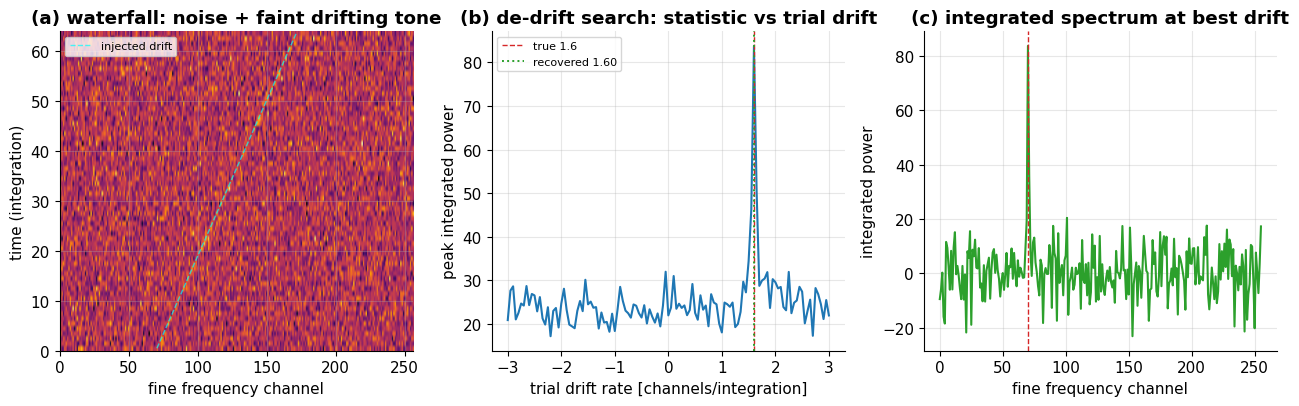

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# (a) the raw waterfall with the (faint) drifting tone.
im = axes[0].imshow(waterfall, aspect="auto", origin="lower", cmap="inferno",
                    extent=[0, N_FREQ, 0, N_TIME])
axes[0].plot(F0_CHAN + TRUE_DRIFT * t + 0.5, t + 0.5, color="cyan", lw=1, ls="--",
             alpha=0.7, label="injected drift")
axes[0].set_xlabel("fine frequency channel")
axes[0].set_ylabel("time (integration)")
axes[0].set_title("(a) waterfall: noise + faint drifting tone")
axes[0].legend(loc="upper left", fontsize=8)

# (b) detection statistic vs trial drift rate.
axes[1].plot(trial_drifts, best_power, color="#1f77b4")
axes[1].axvline(TRUE_DRIFT, color="#d62728", ls="--", lw=1, label=f"true {TRUE_DRIFT}")
axes[1].axvline(recovered_drift, color="#2ca02c", ls=":", lw=1.4,
                label=f"recovered {recovered_drift:.2f}")
axes[1].set_xlabel("trial drift rate [channels/integration]")
axes[1].set_ylabel("peak integrated power")
axes[1].set_title("(b) de-drift search: statistic vs trial drift")
axes[1].legend(fontsize=8)

# (c) integrated spectrum at the best trial -- the detection.
axes[2].plot(best_spectrum, color="#2ca02c")
axes[2].axvline(detected_chan, color="#d62728", ls="--", lw=1)
axes[2].set_xlabel("fine frequency channel")
axes[2].set_ylabel("integrated power")
axes[2].set_title("(c) integrated spectrum at best drift")

fig.tight_layout()
plt.show()

Panel (a) shows the problem: in any single row the tone is fainter than the noise,
and even stacked *without* de-drifting it would smear across many channels. Panel (b)
is the search — the integrated power peaks sharply at the true drift rate. Panel (c)
is the payoff: at the matched drift the tone integrates into one clean spike, far
above the noise floor.

**At scale this is `turboSETI`.** Enriquez et al. (2017),
*The Breakthrough Listen Search for Intelligent Life: 1.1–1.9 GHz observations of
692 nearby stars* ([DOI:10.3847/1538-4357/aa8d1b](https://doi.org/10.3847/1538-4357/aa8d1b)),
ran exactly this de-drift-and-integrate search over filterbank data with sub-Hz
channels and a tree algorithm (the Taylor 1974 "tree de-dispersion" trick, reused
for drift), across drift rates of roughly $\pm 4$ Hz/s. Our toy version is the same
idea in 30 lines and channel units.

## 4. SigMF — portable SDR recordings

The GUPPI file above is great for a Green Bank backend, but if you just want to
**save an SDR capture and share it**, the community standard is
[**SigMF**](https://sigmf.org/) (the Signal Metadata Format). It is gloriously
simple: two files sharing a base name,

- `<base>.sigmf-data` — the raw samples, in a documented binary layout
  (e.g. `cf32_le` = little-endian complex float32, I then Q);
- `<base>.sigmf-meta` — a **JSON** sidecar describing them: datatype, sample rate,
  centre frequency, captures, annotations.

Because the metadata is plain JSON and the data layout is named explicitly, *any*
tool can read a SigMF recording without guessing. Let's round-trip a small IQ
capture with `formats.write_sigmf` / `formats.read_sigmf` and inspect the JSON.

In [9]:
# A small complex-baseband capture: two tones in complex Gaussian noise.
N_IQ = 8192
SAMPLE_RATE = 2.4e6      # Hz
CENTER_FREQ = 1.4204e9   # Hz, near the HI line (flavour)

ni = np.arange(N_IQ)
iq = (1.0 * np.exp(1j * 2 * np.pi * 0.05 * ni)
      + 0.6 * np.exp(1j * 2 * np.pi * -0.18 * ni))
iq = iq + (rng.normal(0, 0.5, N_IQ) + 1j * rng.normal(0, 0.5, N_IQ)) / np.sqrt(2)
iq = iq.astype(np.complex64)

meta_path, data_path = formats.write_sigmf(
    WORKDIR / "capture",
    iq,
    sample_rate=SAMPLE_RATE,
    center_freq=CENTER_FREQ,
    extra_global={"core:description": "jansky Ch16 synthetic IQ capture",
                  "core:author": "jansky course"},
)
print(f"wrote {meta_path.name}  ({meta_path.stat().st_size:,} bytes JSON)")
print(f"wrote {data_path.name}  ({data_path.stat().st_size:,} bytes raw samples)")

wrote capture.sigmf-meta  (361 bytes JSON)
wrote capture.sigmf-data  (65,536 bytes raw samples)


In [10]:
# Read it back and confirm the round-trip is exact.
samples, meta = formats.read_sigmf(WORKDIR / "capture")

print("SigMF metadata (.sigmf-meta JSON):")
print(json.dumps(meta, indent=2))
print()
print(f"recovered {samples.size:,} samples, dtype {samples.dtype}")
print(f"sample rate from metadata: {meta['global']['core:sample_rate']/1e6:.3f} Msps")
print(f"centre freq from metadata: {meta['captures'][0]['core:frequency']/1e9:.6f} GHz")

# The samples should match what we wrote, to float32 precision.
assert samples.shape == iq.shape
assert np.allclose(samples, iq, atol=1e-6)
print("round-trip exact (within float32 precision) -- portable and tool-agnostic.")

SigMF metadata (.sigmf-meta JSON):
{
  "global": {
    "core:datatype": "cf32_le",
    "core:sample_rate": 2400000.0,
    "core:version": "1.0.0",
    "core:num_channels": 1,
    "core:description": "jansky Ch16 synthetic IQ capture",
    "core:author": "jansky course"
  },
  "captures": [
    {
      "core:sample_start": 0,
      "core:frequency": 1420400000.0
    }
  ],
  "annotations": []
}

recovered 8,192 samples, dtype complex64
sample rate from metadata: 2.400 Msps
centre freq from metadata: 1.420400 GHz
round-trip exact (within float32 precision) -- portable and tool-agnostic.


That JSON sidecar is the whole point: a year from now, on a different machine, with
a different toolchain, you (or anyone) can still read the capture because the
metadata says *exactly* what the bytes mean. SigMF is the lingua franca of SDR data
sharing — `gnuradio`, `inspectrum`, and the `sigmf` Python package all speak it.

## 5. Talking to Radio-Sky Spectrograph

[**Radio-Sky Spectrograph**](https://radiosky.com/) (RSS) is a widely used Windows
display program in the amateur / **Radio JOVE** community — it draws live dynamic
spectra of, for example, **decametric (~20 MHz) emission from Jupiter and the Sun**.
Crucially, RSS can take its data over a **TCP socket**, which means *your* code can
be the data source. This is the same path the [**RASDR**](https://github.com/myriadrf/RASDR)
receiver uses to feed RSS.

The protocol (documented in
["How to Talk to Radio-Sky Spectrograph"](http://cygnusa.blogspot.com/2015/07/how-to-talk-to-radio-sky-spectrograph.html)
and the RASDR socket commit) is small and unceremonious:

- RSS listens on **`127.0.0.1:8888`**.
- On connect, the client sends an ASCII config — the **`F | S | O | C`** handshake:
  `F <center_Hz>|S <span_Hz>|O <offset_Hz>|C <n_channels>|`.
- Then it streams each sweep as `n_channels` **little-endian ("LoHi") `uint16`**
  samples (12-bit data, so 0–4095), **highest channel first**, each sweep ended by
  the terminator bytes **`0xFE 0xFE`**. No timestamps, no acknowledgements.

`jansky.formats` ships both a `RSSClient` and an in-process `MockRSSServer`, so we
can drive the *exact* wire format with nothing installed. Let's build a simulated
decametric spectrogram and stream it.

In [11]:
# A simulated decametric dynamic spectrum: a noise storm drifting in frequency,
# the kind of thing RSS displays around 20 MHz.
RSS_CENTER = 20_100_000      # Hz, ~20 MHz decametric band
RSS_SPAN = 4_000_000         # Hz total span
RSS_NCHAN = 256              # RSS supports 100..512 channels
RSS_NSWEEP = 60              # time samples

# Baseline + drifting "storm" lanes, scaled into the 12-bit (0..4095) RSS range.
chan = np.arange(RSS_NCHAN)
sweep_t = np.arange(RSS_NSWEEP)
spectra = np.zeros((RSS_NSWEEP, RSS_NCHAN))
for i in sweep_t:
    base = 800 + rng.normal(0, 40, RSS_NCHAN)          # noise floor
    # A bright emission lane that drifts upward in channel over time.
    lane = 2800 * np.exp(-0.5 * ((chan - (60 + 2.0 * i)) / 12) ** 2)
    # A second, fainter steady lane.
    lane += 1500 * np.exp(-0.5 * ((chan - 180) / 8) ** 2)
    spectra[i] = np.clip(base + lane, 0, formats.RSS_MAX_VALUE)

print(f"simulated {RSS_NSWEEP} sweeps x {RSS_NCHAN} channels, "
      f"values in [0, {formats.RSS_MAX_VALUE}] (12-bit)")
print(f"handshake will be: {formats.rss_handshake(RSS_CENTER, RSS_SPAN, RSS_NCHAN).decode()}")

simulated 60 sweeps x 256 channels, values in [0, 4095] (12-bit)
handshake will be: F 20100000|S 4000000|O 0|C 256|


In [12]:
# Stand up the in-process mock server, stream every sweep through RSSClient,
# then read the decoded sweeps back. This exercises the real F|S|O|C handshake,
# LoHi uint16 encoding, high-channel-first ordering, and 0xFE 0xFE terminator.
server = formats.MockRSSServer()        # binds 127.0.0.1 on an ephemeral port
server.start()
print(f"mock RSS server listening on {server.host}:{server.port}")

with formats.RSSClient(
    center_hz=RSS_CENTER, bandwidth_hz=RSS_SPAN, n_channels=RSS_NCHAN,
    host=server.host, port=server.port,
) as rss:
    for sweep in spectra:
        rss.send_sweep(sweep)

server.join()   # wait for the server thread to finish parsing the stream

print(f"server parsed config: {server.config}")
print(f"server received {len(server.sweeps)} sweeps")
assert server.config["C"] == RSS_NCHAN
assert server.config["F"] == RSS_CENTER
assert len(server.sweeps) == RSS_NSWEEP

mock RSS server listening on 127.0.0.1:36771
server parsed config: {'F': 20100000, 'S': 4000000, 'O': 0, 'C': 256}
server received 60 sweeps


recovered dynamic spectrum: (60, 256)
recovered sweeps match what we streamed, channel-for-channel.


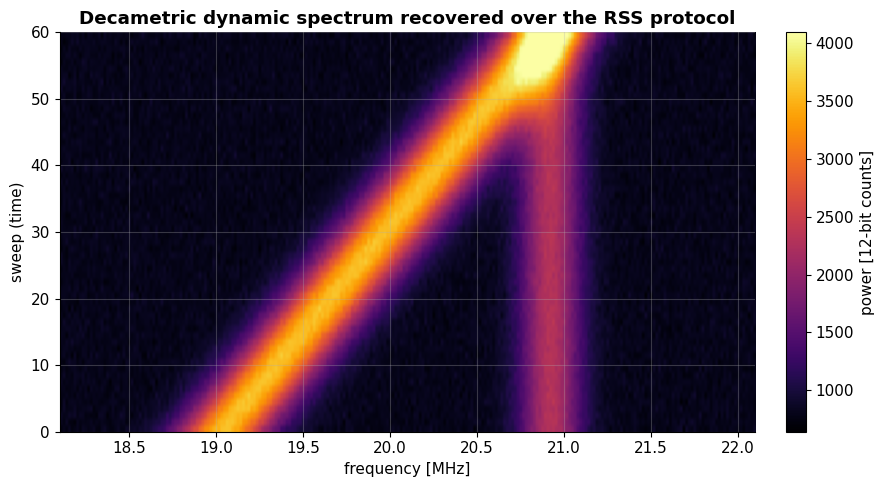

In [13]:
# Reassemble the recovered sweeps into a dynamic spectrum and confirm fidelity.
recovered = np.array(server.sweeps)
print(f"recovered dynamic spectrum: {recovered.shape}")

# The mock decodes back to low->high channel order, matching what we sent
# (after rounding to integers in the 12-bit range).
assert np.array_equal(recovered, np.rint(spectra).astype(int))
print("recovered sweeps match what we streamed, channel-for-channel.")

freq_mhz = (RSS_CENTER + np.linspace(-RSS_SPAN / 2, RSS_SPAN / 2, RSS_NCHAN)) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(recovered, aspect="auto", origin="lower", cmap="inferno",
               extent=[freq_mhz[0], freq_mhz[-1], 0, RSS_NSWEEP])
ax.set_xlabel("frequency [MHz]")
ax.set_ylabel("sweep (time)")
ax.set_title("Decametric dynamic spectrum recovered over the RSS protocol")
fig.colorbar(im, ax=ax, label="power [12-bit counts]", fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

The drifting storm lane and the steady lane both come through intact — and every
byte travelled through the genuine RSS wire format. **To feed the real application
instead**, run Radio-Sky Spectrograph, select its TCP/socket input
(**Options → Radio → RTL Bridge / TCP**), and point `RSSClient` at
`127.0.0.1:8888`:

```python
with formats.RSSClient(center_hz=20_100_000, bandwidth_hz=4_000_000,
                       n_channels=256, host="127.0.0.1", port=8888) as rss:
    for sweep in your_spectra:        # each: 256 channel powers, 0..4095
        rss.send_sweep(sweep)
```

This is the path **RASDR** uses to drive RSS, and it ties directly into the
**Radio JOVE** project — NASA's decametric-radio education kit — whose observers
record Jupiter and solar bursts exactly this way.

> **A note on the `.sps` / `.spd` *file* readers.** RSS can also write its spectra
> to `.sps` files (Typinski 2015) and Radio-SkyPipe writes `.spd`. Those binary
> layouts were not machine-readable when `jansky.formats` was written, and the
> module **does not guess binary formats**: `formats.read_sps()` / `read_spd()`
> raise `NotImplementedError` with a pointer, on purpose. For live data, use the
> RSS protocol above. (See `docs/data-formats.md`.)

In [14]:
# The deferred file readers fail loudly and honestly -- never with fake bytes.
for reader, fname in [(formats.read_sps, "jove.sps"), (formats.read_spd, "chart.spd")]:
    try:
        reader(WORKDIR / fname)
    except NotImplementedError as exc:
        print(f"{reader.__name__}: NotImplementedError (by design)")
        print(f"    -> {exc}")

read_sps: NotImplementedError (by design)
    -> SPS file reading is deferred pending verification against the Typinski (2015) spec; use RSSClient for live data. See docs/data-formats.md.
read_spd: NotImplementedError (by design)
    -> SPD file reading is deferred pending a verified spec. See docs/data-formats.md.


## 6. The wider ecosystem

The formats above are the ones `jansky` handles directly. Everything *downstream* —
visibilities, calibrated images, hydrogen-line spectra — is the domain of mature
community packages. You will not reimplement these; you will install and use them.
Here is the lay of the land, with the heavy import guarded so this cell runs whether
or not the package is present.

**`pyuvdata` / the Radio Astronomy Software Group (RASG).**
[`pyuvdata`](https://radioastronomysoftwaregroup.github.io/) is the interchange hub
for **visibilities**: it reads and writes Measurement Sets (Ch 12), UVFITS, and the
HDF5-based **UVH5**, converting freely between them and exposing the data as NumPy
arrays. It is an optional extra (`uv sync --extra formats`).

In [15]:
try:
    import pyuvdata  # noqa: F401
    HAVE_PYUVDATA = True
    print(f"pyuvdata {pyuvdata.__version__} is available.")
    print("  -> UVData() reads/writes MS <-> UVFITS <-> UVH5 as NumPy visibilities.")
except Exception as exc:
    HAVE_PYUVDATA = False
    print(f"pyuvdata not available ({type(exc).__name__}) -- this is expected on the base env.")
    print("  what it does: the interchange hub for interferometer visibilities --")
    print("    reads/writes Measurement Set (Ch 12), UVFITS, and UVH5, all as NumPy arrays.")
    print("  install with:  uv sync --extra formats")
    print("  docs:          https://radioastronomysoftwaregroup.github.io/")

pyuvdata not available (ModuleNotFoundError) -- this is expected on the base env.
  what it does: the interchange hub for interferometer visibilities --
    reads/writes Measurement Set (Ch 12), UVFITS, and UVH5, all as NumPy arrays.
  install with:  uv sync --extra formats
  docs:          https://radioastronomysoftwaregroup.github.io/


**VIRGO / PICTOR — a no-hardware hydrogen-line route.**
[VIRGO](https://virgo.readthedocs.io/) is a single-dish spectrometer package, and the
engine behind [PICTOR](https://pictortelescope.com/) — a free, web-bookable radio
telescope. Together they let you make a *real* 21 cm hydrogen-line observation with
**no hardware of your own**, complementing the simulated detection in
[Chapter 6](06_hydrogen_line.ipynb). VIRGO is the `hi` extra (`uv sync --extra hi`).
We do not call it here (it would need either hardware or a network booking), but it
is the natural next step for turning Chapter 6's simulation into a measurement.

**CASA — Measurement Sets, calibration, and imaging.**
The Common Astronomy Software Applications package reads/writes Measurement Sets and
does the calibration and imaging you met in [Chapter 12](12_vla_imaging.ipynb). It is
heavyweight (its own `casatools`/`casatasks` install, or the container in
`containers/`), which is exactly why the course keeps it to its own chapter rather
than importing it everywhere.

None of this section makes a network call: it is a map of where to go next, with the
one importable package (`pyuvdata`) guarded above.

## Try it yourself

### Exercise 1 — A two-block GUPPI file

`write_guppi` writes a single block, but real `.raw` files are a *sequence* of
blocks (header + voltages, repeated). Write two GUPPI files with **different tone
channels**, then concatenate their bytes into one file and confirm that
`iter_guppi_blocks` yields **both** blocks in order, each with the right loud
channel. (Hint: `(WORKDIR/"a.raw").read_bytes()` + `(WORKDIR/"b.raw").read_bytes()`,
written to a third path.)

In [16]:
# Exercise 1 starter -- a worked two-block file. Extend it: change the tone
# channels, add a third block, or vary NTIME between blocks.
def make_block(tone_chan, nchan=8, ntime=1024, npol=2, gen=None):
    g = gen if gen is not None else signals.rng(0)
    v = g.integers(-8, 9, (nchan, ntime, npol)) + 1j * g.integers(-8, 9, (nchan, ntime, npol))
    nn = np.arange(ntime)
    v[tone_chan, :, :] += (30.0 * np.exp(1j * 2 * np.pi * 0.1 * nn))[:, None]
    return v

p_a = formats.write_guppi(WORKDIR / "a.raw", make_block(2, gen=signals.rng(1)))
p_b = formats.write_guppi(WORKDIR / "b.raw", make_block(6, gen=signals.rng(2)))

two_block = WORKDIR / "two_block.0000.raw"
two_block.write_bytes(p_a.read_bytes() + p_b.read_bytes())

loud_channels = []
for hdr, volts in formats.iter_guppi_blocks(two_block):
    loud_channels.append(int(np.argmax(np.sum(np.abs(volts) ** 2, axis=(1, 2)))))
print(f"loud channel per block: {loud_channels}  (expected [2, 6])")
assert loud_channels == [2, 6]

loud channel per block: [2, 6]  (expected [2, 6])


### Exercise 2 — Push the drift search to its limit

In the SETI section the tone had per-step SNR 1.2. **Lower it** (try 0.8, 0.5, 0.3)
and rerun the de-drift search. At what SNR does the recovered drift stop matching
the truth? Then **widen the trial grid** or make it **finer** near the peak and see
whether you can claw a fainter signal back. This is the core trade-off in every SETI
pipeline: sensitivity vs the size of the drift search.

In [17]:
# Exercise 2 starter -- sweep the injected SNR and check recovery.
def run_search(tone_snr, gen):
    wf = gen.normal(0.0, 1.0, (N_TIME, N_FREQ))
    cen = F0_CHAN + TRUE_DRIFT * np.arange(N_TIME)
    fa = np.arange(N_FREQ)
    for i, c in enumerate(cen):
        wf[i] += tone_snr * np.exp(-0.5 * ((fa - c) / 0.8) ** 2)
    powers = np.array([dedrift_integrate(wf, d).max() for d in trial_drifts])
    return trial_drifts[int(np.argmax(powers))]

for snr in (1.2, 0.8, 0.5, 0.3):
    rec = run_search(snr, signals.rng(100 + int(snr * 10)))
    ok = "recovered" if abs(rec - TRUE_DRIFT) < 0.2 else "LOST"
    print(f"SNR/step {snr:>3}:  recovered drift {rec:+.2f}  (true {TRUE_DRIFT:+.2f})  [{ok}]")

SNR/step 1.2:  recovered drift +1.60  (true +1.60)  [recovered]

SNR/step 0.8:  recovered drift +1.60  (true +1.60)  [recovered]
SNR/step 0.5:  recovered drift -0.10  (true +1.60)  [LOST]
SNR/step 0.3:  recovered drift -2.00  (true +1.60)  [LOST]


### Exercise 3 — Annotate a SigMF capture

SigMF supports an `annotations` list — labelled spans of samples. Re-save the IQ
capture from Section 4 with an annotation marking the strong tone (its
`core:sample_start`, `core:sample_count`, and a `core:description`), then read it
back and print the annotations. (Hint: `write_sigmf` takes `extra_global`; to add
*annotations* you can write the meta dict yourself with `json`, reusing the data
file `write_sigmf` already produced — the two files are independent.)

In [18]:
# Exercise 3 starter -- add an annotation to the SigMF metadata by hand and re-read.
meta_path = (WORKDIR / "capture").with_suffix(".sigmf-meta")
meta = json.loads(meta_path.read_text())
meta["annotations"] = [{
    "core:sample_start": 0,
    "core:sample_count": N_IQ,
    "core:description": "strong tone at +0.05 cycles/sample",
}]
meta_path.write_text(json.dumps(meta, indent=2))

_, meta_back = formats.read_sigmf(WORKDIR / "capture")
print("annotations after round-trip:")
print(json.dumps(meta_back["annotations"], indent=2))

annotations after round-trip:
[
  {
    "core:sample_start": 0,
    "core:sample_count": 8192,
    "core:description": "strong tone at +0.05 cycles/sample"
  }
]


## Recap

- Radio data flows through a **pipeline of formats** — raw voltages → channelised →
  spectra / visibilities → images — and each stage has its own format and tools.
  The reference is [`docs/data-formats.md`](https://github.com/joebarbere/jansky/blob/main/docs/data-formats.md).
- **GUPPI raw** is the Green Bank / Breakthrough Listen raw-voltage format: FITS-like
  80-byte ASCII cards + interleaved int8 I/Q. We wrote one with
  `formats.write_guppi`, parsed it with `read_guppi_header`, and streamed it with
  `iter_guppi_blocks`, recovering an injected tone in a power-vs-channel plot.
- A **SETI Doppler-drift search** looks for a narrowband signal that drifts
  diagonally across a high-resolution waterfall. De-drift-and-integrate over trial
  drift rates pulls a sub-noise tone out cleanly — the toy version of `turboSETI`.
- **SigMF** is the portable SDR format: raw samples plus a self-describing JSON
  sidecar. We round-tripped a capture with `formats.write_sigmf` / `read_sigmf`.
- **Radio-Sky Spectrograph** takes a live TCP feed (`F|S|O|C` handshake, LoHi
  uint16, high-channel-first, `0xFE 0xFE` terminator). We streamed a decametric
  spectrogram through `formats.RSSClient` into `formats.MockRSSServer` and recovered
  it byte-for-byte — the same path RASDR and Radio JOVE use into the real app.
- The **wider ecosystem** — `pyuvdata`/RASG for visibilities, VIRGO/PICTOR for a
  no-hardware HI line, CASA for Measurement Sets — sits behind guarded imports and
  optional extras, so the base environment stays light.

## What's next

This was the course's tour of the *plumbing* — the formats and tools that move radio
data between the science chapters. From here you can take a real path off the
simulated rails: book a PICTOR observation and reduce it with VIRGO, pull a
Breakthrough Listen `.h5` file and run `turboSETI` for real, or load a VLA
Measurement Set with `pyuvdata` and re-image it. The
[**capstone**](15_capstone.ipynb) ties the science threads together; this chapter
makes sure you can feed it real data when you are ready.